In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/job_salary_prediction_dataset.csv")
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [3]:
df.shape


(250000, 10)

In [4]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [7]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [8]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

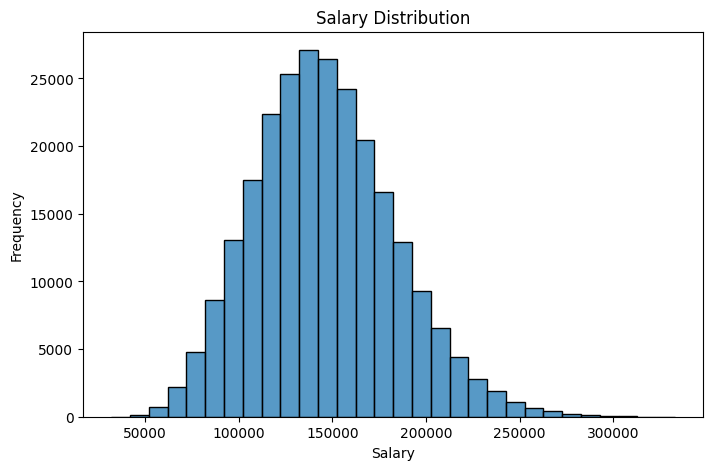

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["salary"], bins=30)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

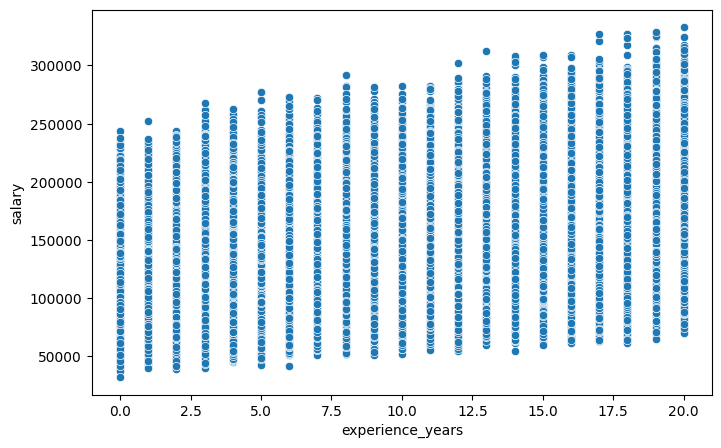

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="experience_years", y="salary", data=df)
plt.show()

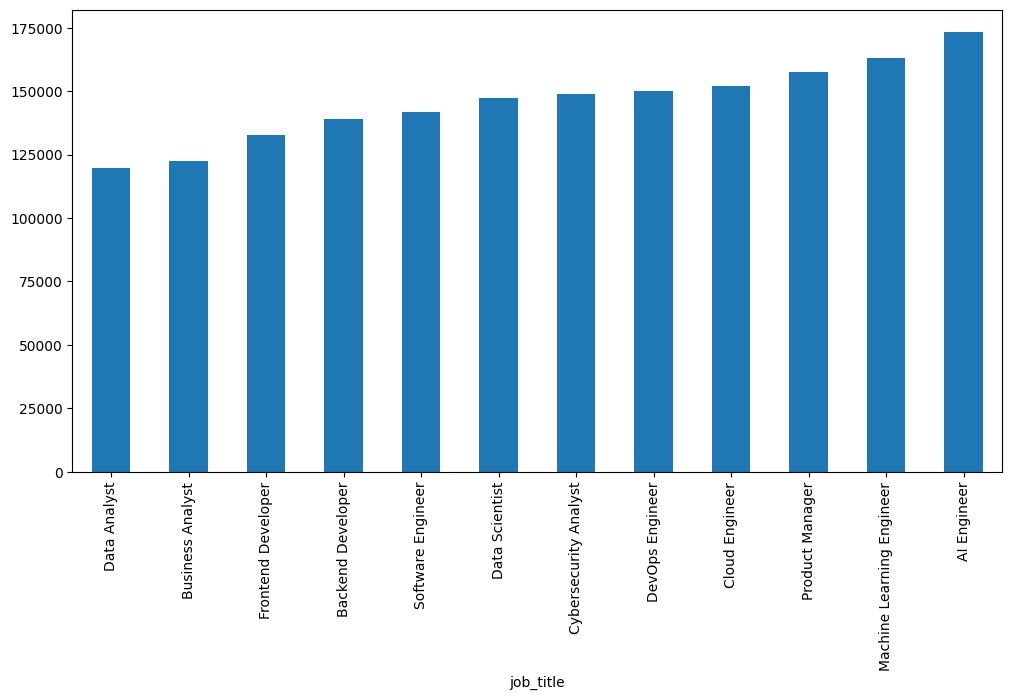

In [12]:
plt.figure(figsize=(12,6))

df.groupby("job_title")["salary"].mean().sort_values().plot(kind="bar")

plt.show()

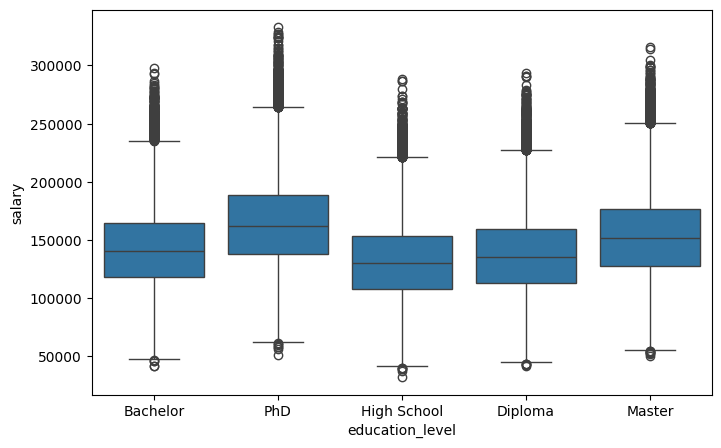

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x="education_level", y="salary", data=df)

plt.show()

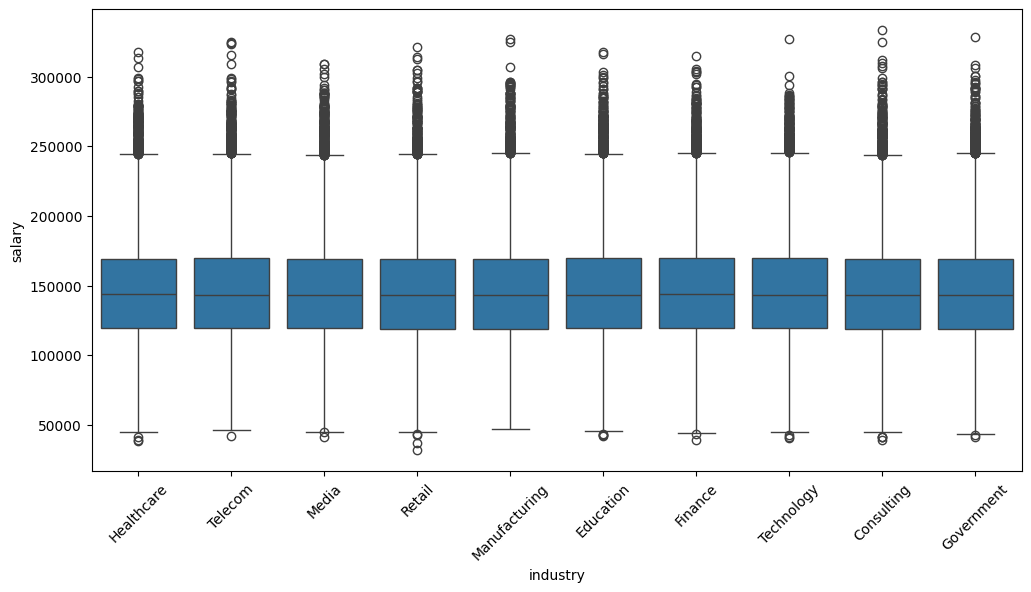

In [14]:
plt.figure(figsize=(12,6))

sns.boxplot(x="industry", y="salary", data=df)

plt.xticks(rotation=45)

plt.show()

<Axes: xlabel='company_size', ylabel='salary'>

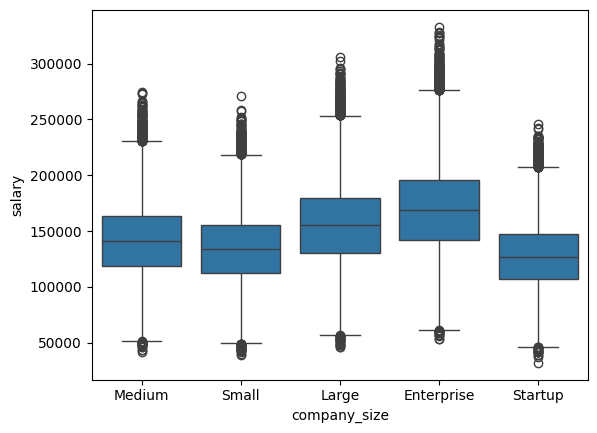

In [15]:
sns.boxplot(
    x="company_size",
    y="salary",
    data=df
)

<Axes: xlabel='remote_work', ylabel='salary'>

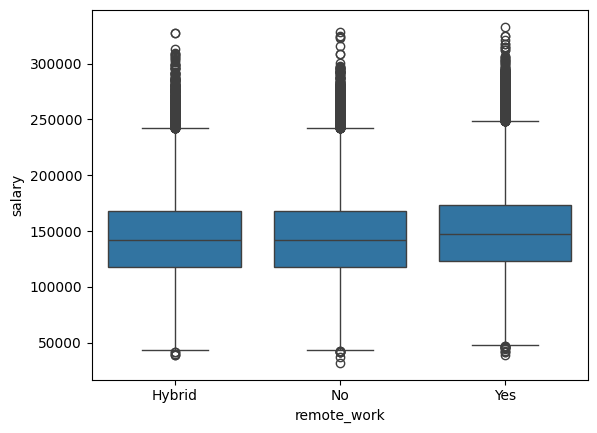

In [16]:
sns.boxplot(
    x="remote_work",
    y="salary",
    data=df
)

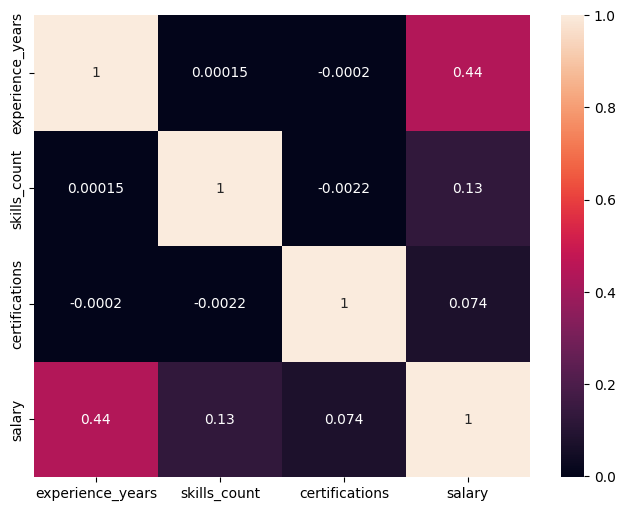

In [17]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(8,6))

sns.heatmap(numeric_df.corr(), annot=True)

plt.show()

In [18]:
X = df.drop("salary", axis=1)

y = df["salary"]

In [19]:
X = pd.get_dummies(X, drop_first=True)

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

In [22]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )

}

In [23]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    prediction = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, prediction)

    rmse = np.sqrt(
        mean_squared_error(y_test, prediction)
    )

    r2 = r2_score(y_test, prediction)

    return mae, rmse, r2

In [24]:
results = []

for model_name, model in models.items():

    mae, rmse, r2 = evaluate_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

In [25]:
results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,5436.096937,7125.522904,0.963469
1,Decision Tree,7983.791490,10456.111274,0.921337
2,Random Forest,5693.018592,7375.756853,0.960858
3,Gradient Boosting,8871.415591,11822.961017,0.899427


In [26]:
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,5436.096937,7125.522904,0.963469
2,Random Forest,5693.018592,7375.756853,0.960858
1,Decision Tree,7983.791490,10456.111274,0.921337
3,Gradient Boosting,8871.415591,11822.961017,0.899427


In [27]:
best_model_name = results_df.iloc[0]["Model"]

print(best_model_name)

Linear Regression


In [28]:
best_model = models[best_model_name]

In [29]:
import joblib

joblib.dump(
    best_model,
    "../models/salary_prediction.pkl"
)

['../models/salary_prediction.pkl']

In [30]:
print("="*50)

print("Best Model :", best_model_name)

print(results_df)

print("="*50)

Best Model : Linear Regression
               Model          MAE          RMSE  R2 Score
0  Linear Regression  5436.096937   7125.522904  0.963469
2      Random Forest  5693.018592   7375.756853  0.960858
1      Decision Tree  7983.791490  10456.111274  0.921337
3  Gradient Boosting  8871.415591  11822.961017  0.899427


In [32]:
print(results_df)

               Model          MAE          RMSE  R2 Score
0  Linear Regression  5436.096937   7125.522904  0.963469
2      Random Forest  5693.018592   7375.756853  0.960858
1      Decision Tree  7983.791490  10456.111274  0.921337
3  Gradient Boosting  8871.415591  11822.961017  0.899427


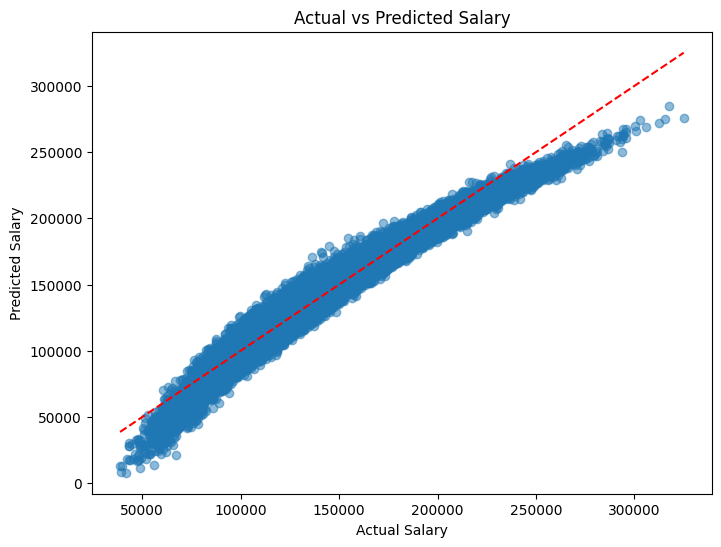

In [34]:
import matplotlib.pyplot as plt

predictions = best_model.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions, alpha=0.5)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.show()

In [35]:
final_model = best_model


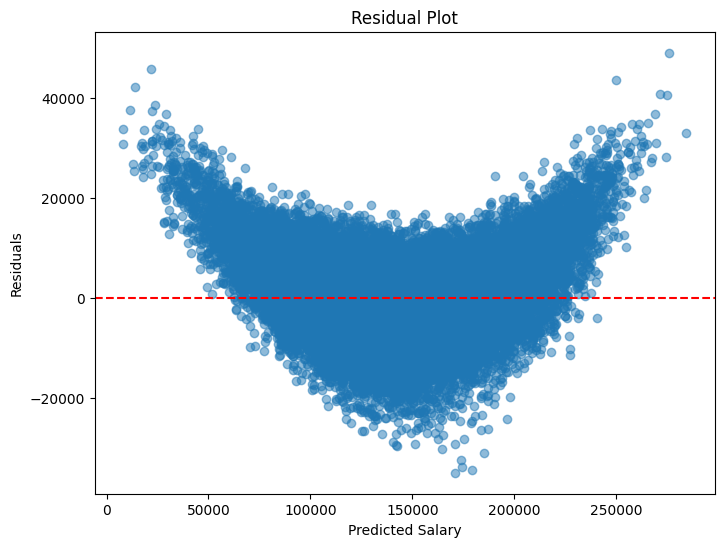

In [36]:
predictions = final_model.predict(X_test)
residuals = y_test - predictions

plt.figure(figsize=(8,6))
plt.scatter(predictions, residuals, alpha=0.5)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [37]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": final_model.coef_
})

coefficients.head()

,Feature,Coefficient
0,experience_years,2698.565043
1,skills_count,857.188031
2,certifications,1613.176976
3,job_title_Backend Developer,-34320.496286
4,job_title_Business Analyst,-51542.574321


In [38]:
coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
39,location_USA,41971.549495
31,location_Canada,27941.449186
17,education_level_PhD,21532.269290
38,location_UK,20967.211802
32,location_Germany,13988.379511
16,education_level_Master,10829.817459
41,remote_work_Yes,5338.885135
0,experience_years,2698.565043
2,certifications,1613.176976
1,skills_count,857.188031


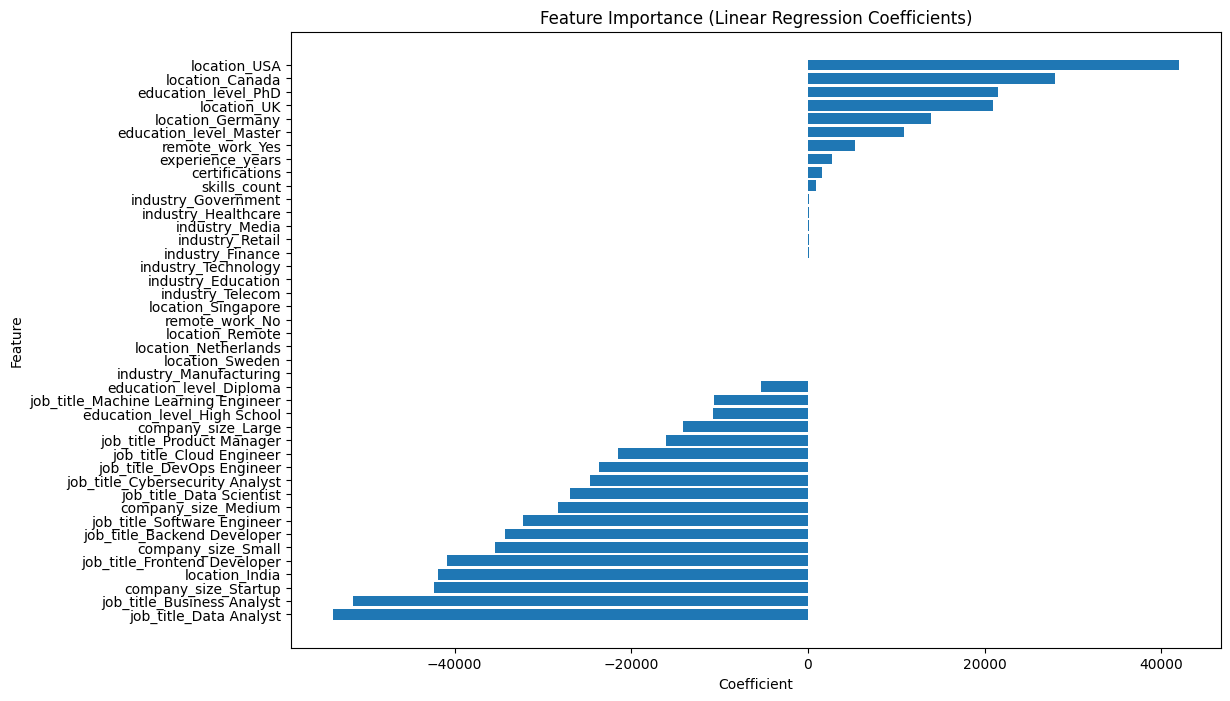

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.title("Feature Importance (Linear Regression Coefficients)")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

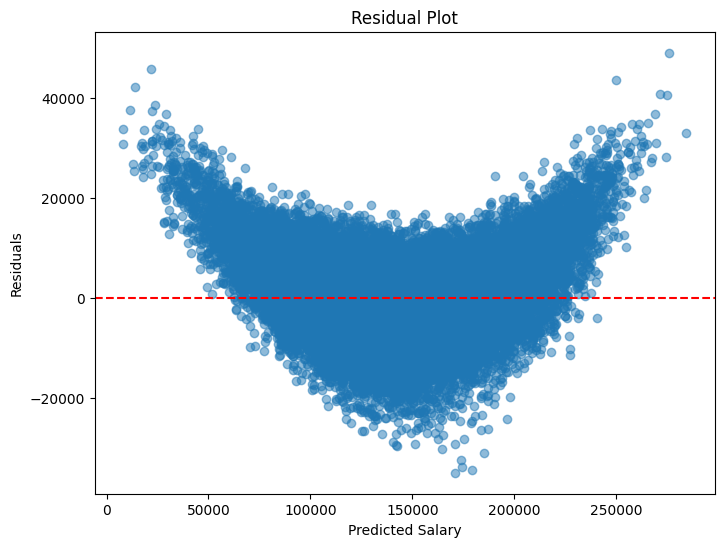

In [40]:
predictions = final_model.predict(X_test)

residuals = y_test - predictions

plt.figure(figsize=(8,6))

plt.scatter(predictions, residuals, alpha=0.5)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [41]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    final_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross-validation scores:", scores)
print("Average R²:", scores.mean())

Cross-validation scores: [0.96368078 0.96332835 0.96325859 0.96338034 0.96319994]
Average R²: 0.9633695979784109


In [42]:
import joblib

joblib.dump(
    final_model,
    "../models/salary_prediction.pkl"
)

['../models/salary_prediction.pkl']

In [43]:
import joblib

joblib.dump(X.columns.tolist(), "../models/columns.pkl")

['../models/columns.pkl']

In [44]:
print(df["job_title"].unique())

print(df["education_level"].unique())

print(df["industry"].unique())

print(df["company_size"].unique())

print(df["location"].unique())

print(df["remote_work"].unique())

['AI Engineer' 'Data Analyst' 'Frontend Developer' 'Business Analyst'
 'Product Manager' 'Backend Developer' 'Machine Learning Engineer'
 'DevOps Engineer' 'Software Engineer' 'Cybersecurity Analyst'
 'Data Scientist' 'Cloud Engineer']
['Bachelor' 'PhD' 'High School' 'Diploma' 'Master']
['Healthcare' 'Telecom' 'Media' 'Retail' 'Manufacturing' 'Education'
 'Finance' 'Technology' 'Consulting' 'Government']
['Medium' 'Small' 'Large' 'Enterprise' 'Startup']
['India' 'Australia' 'Singapore' 'Canada' 'Sweden' 'USA' 'Netherlands'
 'Remote' 'Germany' 'UK']
['Hybrid' 'No' 'Yes']


In [45]:
import joblib

joblib.dump(final_model, "../models/salary_prediction.pkl")
joblib.dump(X.columns.tolist(), "../models/columns.pkl")

['../models/columns.pkl']